### train the linear CCA model by single pair of 0.1tau time-lagged configurations at T=0.47 

In [1]:
import numpy as np
import torch
from tcca import linear_cca

pastdata = np.load("T=0.47_time=0.0tau_radial_gaussian_features.npy", allow_pickle=True)[:3277][:, 0:200]
futuredata = np.load("T=0.47_time=0.1tau_radial_gaussian_features.npy", allow_pickle=True)[:3277][:, 0:200]
propensity = np.loadtxt("./T=0.47_select_time_propensities_isoconfigurational_results.txt")
time = propensity[0]; propensity = propensity[1:]

pastdata = torch.from_numpy(pastdata); futuredata = torch.from_numpy(futuredata)
traindata = torch.utils.data.TensorDataset(pastdata, futuredata)
train_loader = torch.utils.data.DataLoader(dataset=traindata, batch_size=int(len(traindata)), shuffle=False, num_workers=1)

cca = linear_cca(symmetrize=True, kinetic_mapping=True, shrinkage=False)
encoder, decoder, koopman = cca.fit(dataloader=train_loader, dim=2)

encoder = encoder.t().numpy()
sqrt_c00 = cca._sqrt_c00.t().numpy()
components = np.dot(sqrt_c00, encoder)
project_pastconfig, project_futureconfig = cca.transform(train_loader)

### correlate the leading order parameters with propensities at different time

In [2]:
from scipy import stats

correlation1 = []; correlation2 = []; 
for t in range(len(time)):
    correlation1.append(stats.pearsonr(project_pastconfig[:, 0], propensity[:, t]).statistic)
    correlation2.append(stats.pearsonr(project_pastconfig[:, 1], propensity[:, t]).statistic)
correlation1 = np.abs(np.array(correlation1)); correlation2 = np.abs(np.array(correlation2))

findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.


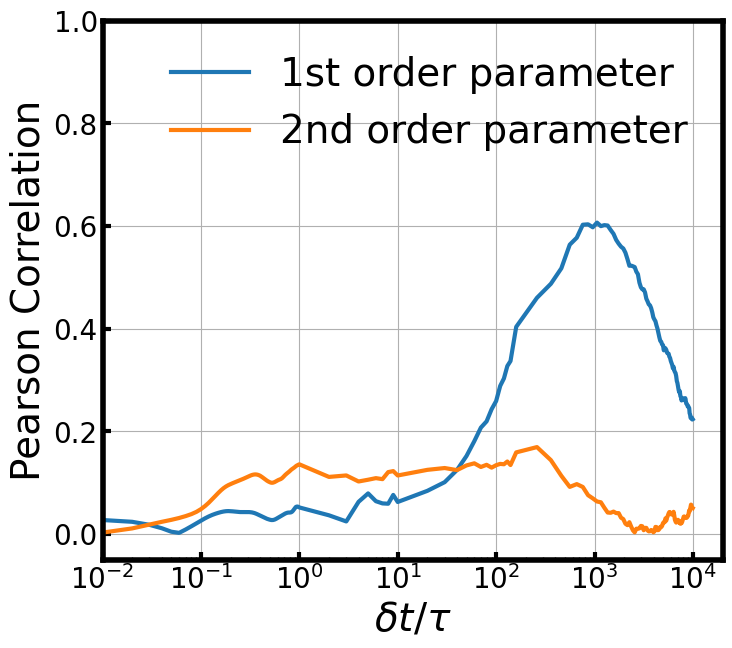

In [3]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 7))     
plt.plot(time, correlation1, label="1st order parameter", linewidth=3.0)
plt.plot(time, correlation2, label="2nd order parameter", linewidth=3.0)
plt.tick_params(which='major', width=3, direction='in', labelsize=15, length=6)
plt.tick_params(which='minor', width=1, direction='in', length=2)
ax.set_xscale("log")
plt.ylim(-0.05, 1.0)
plt.xlim(1e-2, 2e4)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.spines['bottom'].set_linewidth(4.0)
ax.spines['left'].set_linewidth(4.0)
ax.spines['top'].set_linewidth(4.0)
ax.spines['right'].set_linewidth(4.0)
legend_font = {'family':"Times New Roman", 'size':28}
plt.legend(loc='upper right', prop=legend_font, ncol=1, frameon=False)
ax.xaxis.get_offset_text().set_fontsize(19)
plt.ylabel("Pearson Correlation", fontdict={'size':28})
plt.xlabel("$\delta t/ \\tau$", fontdict={'size':28})
plt.grid()

### visualize the order parameters and color the embeded particles by propensties at 960 tau

Text(0, 0.5, 'Order Parameter 2')

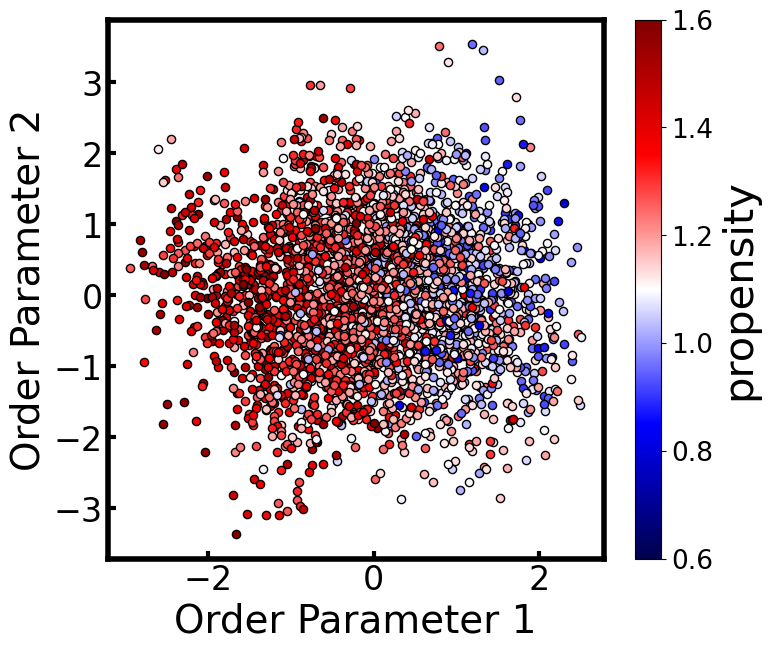

In [4]:
tau = 130
cm = plt.cm.get_cmap("seismic")
z = np.linspace(0, 1, 20)
min_propensity = 0.6
max_propensity = 1.6


fig, ax = plt.subplots(figsize=(8, 7)) 
for i in range(3277):
    plt.scatter(project_pastconfig[i, 0], project_pastconfig[i,1], c=propensity[i, tau], vmin=min_propensity, vmax=max_propensity, s=35, cmap=cm, edgecolors='black')
cb = plt.colorbar()
cb.ax.tick_params(labelsize=19)
cb.set_label('propensity',fontsize=30)
ax.spines['bottom'].set_linewidth(4.0)
ax.spines['left'].set_linewidth(4.0)
ax.spines['top'].set_linewidth(4.0)
ax.spines['right'].set_linewidth(4.0)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.tick_params(which='major', width=3, direction='in', labelsize=24, length=6)
plt.tick_params(which='minor', width=1, direction='in', length=0)
plt.xlabel("Order Parameter 1", fontdict={'size':28})
plt.ylabel("Order Parameter 2", fontdict={'size':28})

### do the Gaussian Mixture clustering in the order parameter space

In [5]:
from sklearn.mixture import GaussianMixture

relation = 0
for seed in range(300):
    gm = GaussianMixture(n_components=2, random_state=seed).fit(project_pastconfig)
    likelihood = gm.predict_proba(project_pastconfig)
    a = stats.pearsonr(likelihood[:, 1], propensity[:, 130]).statistic
    if a > relation:
        relation = a
        print("seed = {}, the correlation is maximized to: {};".format(seed, a))

seed = 1, the correlation is maximized to: 0.25057165640829154;
seed = 4, the correlation is maximized to: 0.580101021090918;
seed = 84, the correlation is maximized to: 0.5818352578796161;
